<a href="https://colab.research.google.com/github/amandachipolito/Trabalho-BCI/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Instalar Bibliotecas

In [ ]:
!python3 -m pip install --upgrade pip
!pip download numpy pathlib scipy gdown matplotlib scikit-learn
!pip install numpy pathlib scipy gdown matplotlib scikit-learn


Python was not found; run without arguments to install from the Microsoft Store, or disable this shortcut from Settings > Apps > Advanced app settings > App execution aliases.


  File was already downloaded c:\users\caiom\trabalho-bci\numpy-2.4.4-cp314-cp314-win_amd64.whl
  File was already downloaded c:\users\caiom\trabalho-bci\pathlib-1.0.1-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\scipy-1.17.1-cp314-cp314-win_amd64.whl
  File was already downloaded c:\users\caiom\trabalho-bci\gdown-6.0.0-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\matplotlib-3.10.9-cp314-cp314-win_amd64.whl
  File was already downloaded c:\users\caiom\trabalho-bci\scikit_learn-1.8.0-cp314-cp314-win_amd64.whl
  File was already downloaded c:\users\caiom\trabalho-bci\beautifulsoup4-4.14.3-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\filelock-3.29.0-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\requests-2.33.1-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\tqdm-4.67.3-py3-none-any.whl
  File was already downloaded c:\users\caiom\trabalho-bci\co


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m ensurepip --default-pip

# 2 - Importar Bibliotecas

In [485]:
import glob
import os
import sys
import numpy as np
from pathlib import Path
from scipy.io import loadmat


# 3 - Definir pasta local e link do Google Drive

In [486]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: C:\Users\caiom\Trabalho-BCI\Projeto_BCI


# 4 - Baixar arquivos .mat

In [487]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

A pasta já existe. Download não realizado novamente.


# 5 - Listar arquivos encontrados

In [488]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

8 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat
covertShiftsOfAttention_VPiae.mat
covertShiftsOfAttention_VPiah.mat
covertShiftsOfAttention_VPiai.mat
covertShiftsOfAttention_VPmk.mat
covertShiftsOfAttention_VPnh.mat


# 6 - Carregar os dados corretamente

In [489]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiae.mat
  X shape: (613408, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiah.mat
  X shape: (604788, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiai.mat
  X shape: (429348, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPmk.mat
  X shape: (592640, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPnh.mat
  X shape: (596576, 62)
  fs: 200 Hz



# 7 - Conferir se todos tem a mesma frequência de amostragem

In [490]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


# 8 - Conferir o formato dos dados

In [491]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 9 - Criar a função de filtragem

In [492]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [8, 14],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado

# 10 - Filtrar todos os participantes

In [493]:
data_filtrada = []

for X, fs, nome in zip(data_list, fs_list, nomes_arquivos):
    print(f"Filtrando {nome}...")

    X_filtrado = aplicar_filtros_eeg(X, fs)

    data_filtrada.append(X_filtrado)

    print(f"  Antes: {X.shape}")
    print(f"  Depois: {X_filtrado.shape}")
    print()

Filtrando covertShiftsOfAttention_VPgao.mat...
  Antes: (579736, 62)
  Depois: (579736, 62)

Filtrando covertShiftsOfAttention_VPiaa.mat...
  Antes: (581804, 62)
  Depois: (581804, 62)

Filtrando covertShiftsOfAttention_VPiac.mat...
  Antes: (657660, 62)
  Depois: (657660, 62)

Filtrando covertShiftsOfAttention_VPiae.mat...
  Antes: (613408, 62)
  Depois: (613408, 62)

Filtrando covertShiftsOfAttention_VPiah.mat...
  Antes: (604788, 62)
  Depois: (604788, 62)

Filtrando covertShiftsOfAttention_VPiai.mat...
  Antes: (429348, 62)
  Depois: (429348, 62)

Filtrando covertShiftsOfAttention_VPmk.mat...
  Antes: (592640, 62)
  Depois: (592640, 62)

Filtrando covertShiftsOfAttention_VPnh.mat...
  Antes: (596576, 62)
  Depois: (596576, 62)



# 11 - Verificar resultado final

In [494]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 8
Total de arquivos filtrados: 8

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


# 12 - Plotar alguns canais do EEG

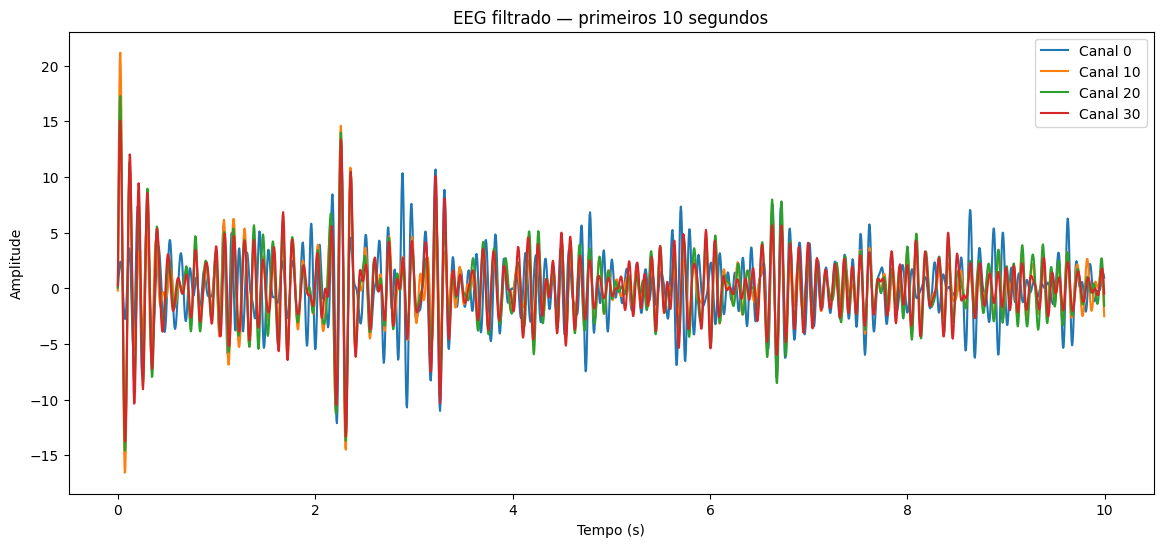

In [495]:
import matplotlib.pyplot as plt

idx_participante = 0
X = data_filtrada[idx_participante]

fs = fs_list[idx_participante]

tempo = np.arange(X.shape[0]) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        X[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG filtrado — primeiros 10 segundos")
plt.legend()
plt.show()

# 13 - Inspecionar estrutura dos trials

In [496]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


# 14 - Calcular duração dos trials

In [497]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


# 15 - Inspecionar estrutura dos eventos cue/target

In [498]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 15.1 - Inspecionar conteúdo dos campos de target_location

In [499]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


# 16 - Calcular delay entre cue e target

In [500]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


# 17 - Criar epochs alinhadas ao cue

Nesta etapa segmentamos o sinal EEG filtrado usando os instantes de cue
como referência temporal.

Cada epoch será extraída do intervalo entre:

cue → target

Esse intervalo representa o período em que o participante recebeu o cue
e manteve a atenção encoberta até o surgimento do target.

Cada epoch será armazenada como uma matriz:

[n_amostras × n_canais]

In [501]:
idx_participante = 0

X = data_filtrada[idx_participante]

cue_pos = data.trial
target_pos = mrk.target_location.pos
target_y = mrk.target_location.y

epochs_cue_target = []
labels_cue_target = []

for i in range(len(cue_pos)):

    inicio = cue_pos[i]
    fim = target_pos[i]

    if fim > inicio and fim <= X.shape[0]:

        epoch = X[inicio:fim, :]

        classe = np.argmax(target_y[:, i])

        epochs_cue_target.append(epoch)
        labels_cue_target.append(classe)

labels_cue_target = np.array(labels_cue_target)

print("Número de epochs criadas:", len(epochs_cue_target))
print("Número de labels:", len(labels_cue_target))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target[:10])

Número de epochs criadas: 600
Número de labels: 600

Primeiras shapes das epochs:
Epoch 0: (429, 62)
Epoch 1: (192, 62)
Epoch 2: (430, 62)
Epoch 3: (429, 62)
Epoch 4: (271, 62)

Primeiros labels:
[1 0 2 0 1 3 0 5 1 2]


# 18 - Padronizar tamanho das epochs usando delay mínimo

Como os intervalos cue→target variam entre trials,
definimos o tamanho da janela fixa com base no menor delay encontrado.

Isso garante que todas as epochs tenham o mesmo tamanho
sem remover trials.

A janela final será:

cue → cue + delay_mínimo

In [502]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target, labels_cue_target):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

Janela escolhida (amostras): 129
Janela escolhida (segundos): 0.645



Shape final das epochs:
(600, 129, 62)

Shape final dos labels:
(600,)

Total de trials mantidos: 600


# 19 - ICA:

In [534]:
import mne
from mne.preprocessing import ICA

# 1. Preparando os metadados para o MNE
# Criamos uma lista com nomes genéricos para os 62 canais
ch_names = [f'EEG_{i:03d}' for i in range(62)]
ch_types = ['eeg'] * 62
info = mne.create_info(ch_names=ch_names, sfreq=200, ch_types=ch_types)

# 2. Convertendo NumPy Array para MNE Epochs
# IMPORTANTE: Transpomos de (600, 129, 62) para (600, 62, 129)
data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

# 3. Configurando o ICA
# 'n_components=20' é um bom ponto de partida para 62 canais
# 'method=fastica' é o padrão estável
ica = ICA(n_components=20, random_state=42, method='fastica')

# 4. Treinando o ICA nos dados
print("Iniciando o ajuste do ICA (isso pode levar alguns segundos)...")
ica.fit(epochs_mne)

print("\nICA ajustado com sucesso!")
print(f"Número de componentes encontrados: {ica.n_components_}")

Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Iniciando o ajuste do ICA (isso pode levar alguns segundos)...
Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\caiom\AppData\Local\Temp\ipykernel_22248\2849279526.py:22: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 3.0s.

ICA ajustado com sucesso!
Número de componentes encontrados: 20


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\caiom\AppData\Local\Temp\ipykernel_22248\2455908270.py:22: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 2.4s.
Gerando mapas topográficos... Procure por componentes com picos frontais (olhos).


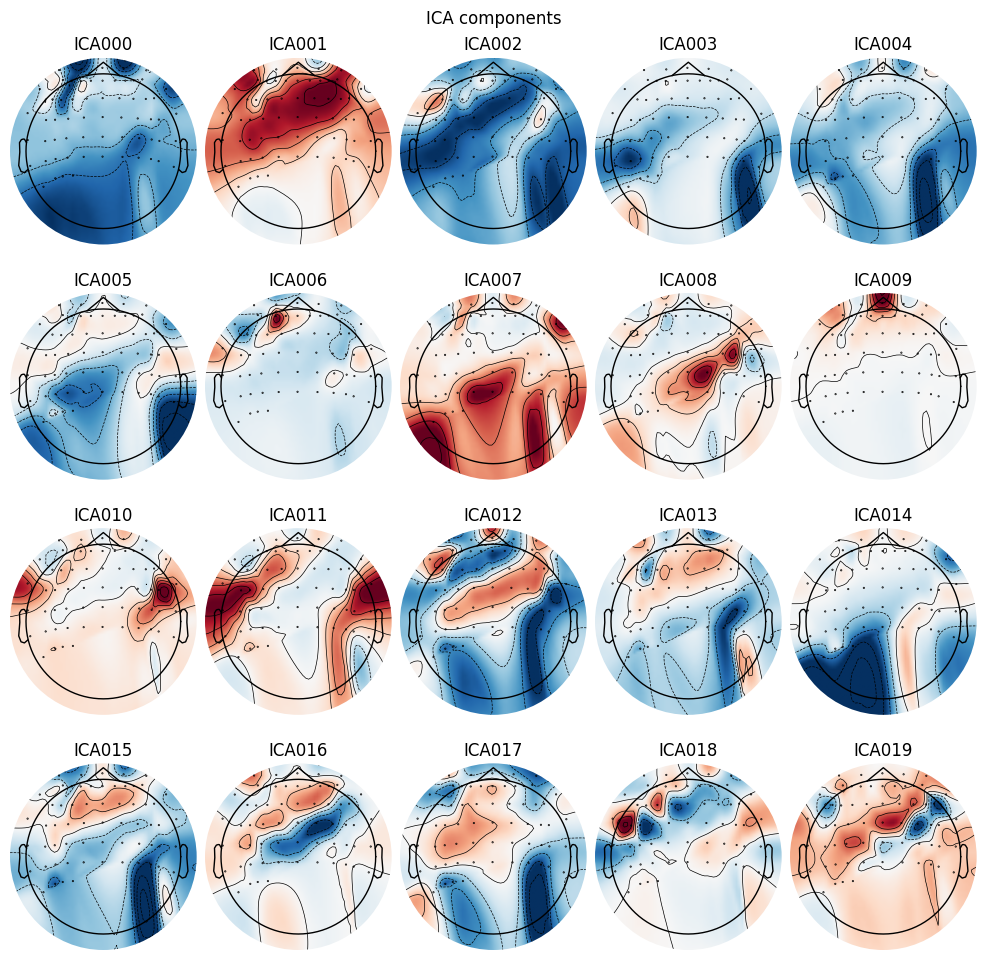

Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated


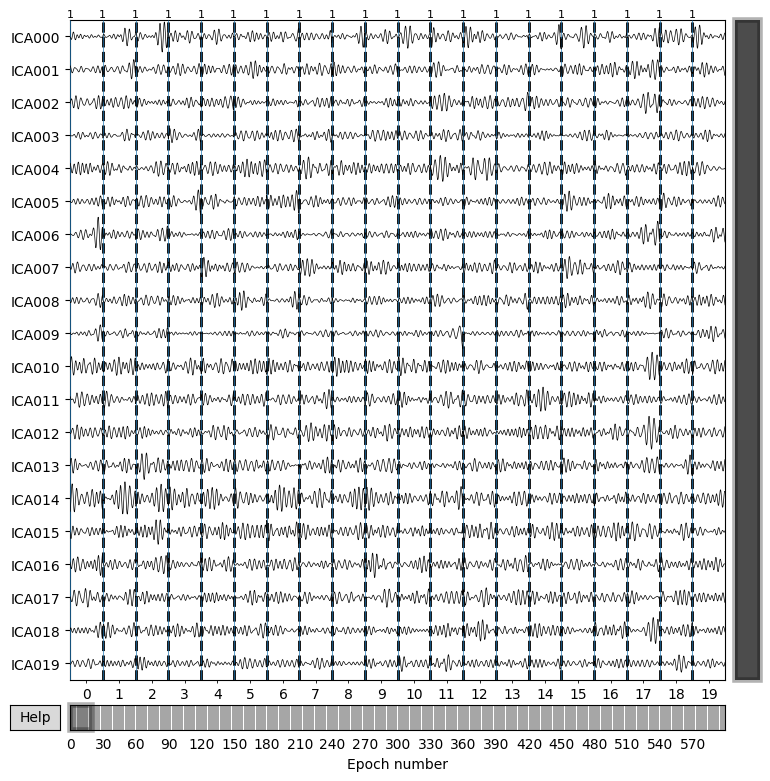

Aplicando limpeza: removendo componentes [0, 1]
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 62 PCA components

PROCESSO ICA CONCLUÍDO
Shape resultante: (600, 129, 62)


In [535]:
import mne
import numpy as np
from mne.preprocessing import ICA

# 1. Obter nomes padrão do sistema 10-20 para os 62 canais
# Isso é um "truque" para que o MNE saiba onde desenhar cada ponto
montage_std = mne.channels.make_standard_montage('standard_1020')
std_ch_names = montage_std.ch_names[:62] # Pegamos os primeiros 62 nomes padrão

# 2. Criar Info e aplicar a Montagem
info = mne.create_info(ch_names=std_ch_names, sfreq=200, ch_types='eeg')
info.set_montage(montage_std)

# 3. Criar o objeto MNE Epochs
# Transpomos de (600, 129, 62) para (600, 62, 129)
data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

# 4. Ajustar (Fit) o ICA
# O aviso de High-pass pode aparecer, mas como seus dados já estão filtrados, pode prosseguir
ica = ICA(n_components=20, random_state=42, method='fastica')
ica.fit(epochs_mne)

# 5. Visualização (Agora os mapas devem aparecer!)
print("Gerando mapas topográficos... Procure por componentes com picos frontais (olhos).")
ica.plot_components()
ica.plot_sources(epochs_mne)

# =================================================================
# PARTE DE LIMPEZA (Edite os números em 'exclude' após ver os gráficos)
# =================================================================
# Geralmente os olhos são os componentes 0, 1 ou 2.
ica.exclude = [0, 1] 

print(f"Aplicando limpeza: removendo componentes {ica.exclude}")
epochs_limpas = ica.apply(epochs_mne.copy())

# 6. Conversão final para NumPy (Voltando ao seu formato original)
#epochs_padronizadas_clean = epochs_limpas.get_data().transpose(0, 2, 1)

print("\n" + "="*30)
print("PROCESSO ICA CONCLUÍDO")
print(f"Shape resultante: {epochs_padronizadas_clean.shape}")
print("="*30)

# 19 - Extração da Potência Alfa via Método de Welch:

Nessa etapa, será realizada a extração de características espectrais dos sinais de EEG processados. Dessa forma, utilizamos o Método de Welch para calcular a Densidade Espectral de Potência (PSD) em cada um dos 62 canais de forma independente.  

In [ ]:
#import numpy as np
#from scipy.signal import welch

# 1. Configurações base
#fs = 200
# MODIFICAÇÃO 1: Pega o número dinâmico de canais para não dar erro
#n_canais = epochs_padronizadas_clean.shape[2] 
#indices_posteriores = list(range(n_canais))

#X_welch_raw = []

#print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")

#for trial in epochs_padronizadas_clean:
    #trial_psds = []
    
    # Calculamos o PSD para cada canal individualmente
    #for ch_idx in indices_posteriores:
        #freqs, psd = welch(trial[:, ch_idx], fs=fs, nperseg=trial.shape[0])
        #trial_psds.append(psd)
        
    #X_welch_raw.append(trial_psds)

# Convertendo para array NumPy (Trials, Canais, Frequências)
#X_welch_raw = np.array(X_welch_raw)

# MODIFICAÇÃO 2: Preparando para o SVM (Isolando Alfa e aplicando Log10)
#idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]
# Tira a média apenas da banda alfa e aplica o logaritmo
#X_features_welch = np.log10(np.mean(X_welch_raw[:, :, idx_alfa], axis=-1))

#print("\n" + "="*30)
#print("PSD CALCULADO (WELCH PURO)")
#print(f"Shape para o SVM: {X_features_welch.shape}")
#print("="*30)

Calculando PSD via Welch para 600 trials...

PSD CALCULADO (WELCH PURO)
Shape para o SVM: (600, 62)


In [605]:
import numpy as np
from scipy.signal import welch

# 1. Configurações base
fs = 200

# Selecionando exatamente os 32 canais posteriores (índices 30 a 62)
# Isso garante que o shape final seja (600, 32)
indices_canais = list(range(30, 62)) 
n_canais_selecionados = len(indices_canais)

X_welch_raw = []

print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")
print(f"Foco: {n_canais_selecionados} canais posteriores selecionados.")

for trial in epochs_padronizadas_clean:
    trial_psds = []
    
    # Calculamos o PSD apenas para os canais do intervalo definido
    for ch_idx in indices_canais:
        # nperseg=256 e noverlap=128 para reduzir a variância (suavizar ruído)
        freqs, psd = welch(trial[:, ch_idx], 
                           fs=fs, 
                           nperseg=256, 
                           noverlap=128)
        trial_psds.append(psd)
    
    X_welch_raw.append(trial_psds)

# Convertendo para array NumPy 3D (Trials, Canais, Frequências)
X_welch_raw = np.array(X_welch_raw)

# =================================================================
# COMPRESSÃO PARA O SVM (Transformando 3D em 2D)
# =================================================================
# 1. Encontramos os índices das frequências da Banda Alfa (8 a 14 Hz)
idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]

# 2. Tiramos a média da banda alfa para cada um dos 32 canais
X_features_welch = np.mean(X_welch_raw[:, :, idx_alfa], axis=-1)

# 3. Aplicamos o Log10 com constante de estabilidade (evita -inf)
X_features_welch = np.log10(X_features_welch + 1e-10)

print("\n" + "="*40)
print("PSD CALCULADO (WELCH SUAVIZADO)")
print(f"Shape bruto: {X_welch_raw.shape}")
print(f"Shape final para o SVM: {X_features_welch.shape}") 
print(f"Canais processados: {n_canais_selecionados} (Posteriores)")
print("="*40)

Calculando PSD via Welch para 600 trials...
Foco: 32 canais posteriores selecionados.


C:\Users\caiom\AppData\Local\Temp\ipykernel_22248\1700132476.py:23: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 129, using nperseg = 129
  freqs, psd = welch(trial[:, ch_idx],



PSD CALCULADO (WELCH SUAVIZADO)
Shape bruto: (600, 32, 65)
Shape final para o SVM: (600, 32)
Canais processados: 32 (Posteriores)


# 19 - Converter epochs para matriz 2D

Nesta etapa convertemos as epochs tridimensionais:

[n_trials × n_amostras × n_canais]

em uma matriz bidimensional:

[n_trials × n_features]

Cada epoch será transformada em um vetor único,
permitindo o uso de métodos como PCA e classificadores.

# 20 - Padronizar os dados (z-score)

Nesta etapa padronizamos cada feature para ter:

média = 0  
desvio padrão = 1  

Essa transformação é necessária antes da aplicação do PCA, pois padroniza os valores de potência da banda Alfa extraídos no bloco anterior e garante que a potência de todos os eletrodos contribua de forma equilibrada para o cálculo da matriz de covariância, evitando que canais com amplitudes maiores dominem a análise das direções principais de variância espacial.

In [606]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()

#X_padronizado = scaler.fit_transform(X_features)

print("Shape após padronização:")
print(X_padronizado.shape)

print("\nMédia aproximada (primeiras features):")
print(np.mean(X_padronizado[:, :5], axis=0))

print("\nDesvio padrão aproximado (primeiras features):")
print(np.std(X_padronizado[:, :5], axis=0))

Shape após padronização:
(600, 62)

Média aproximada (primeiras features):
[ 7.38020756e-16 -8.85402862e-17  6.47630098e-19 -2.50540329e-16
 -8.44232092e-17]

Desvio padrão aproximado (primeiras features):
[1. 1. 1. 1. 1.]


# Classificador SVM pós extração de atributos via Welch:

Treinando modelo Binário...
Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...

RESUMO DE PERFORMANCE (BASELINE)
Dados de Entrada: Welch + Log10 (Banda Alfa | 32 Canais)
Melhores parâmetros Multiclasse: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia Binária (Direção 0 vs 1): 61.77%
Acurácia Multiclasse (Todas as 6): 20.17%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


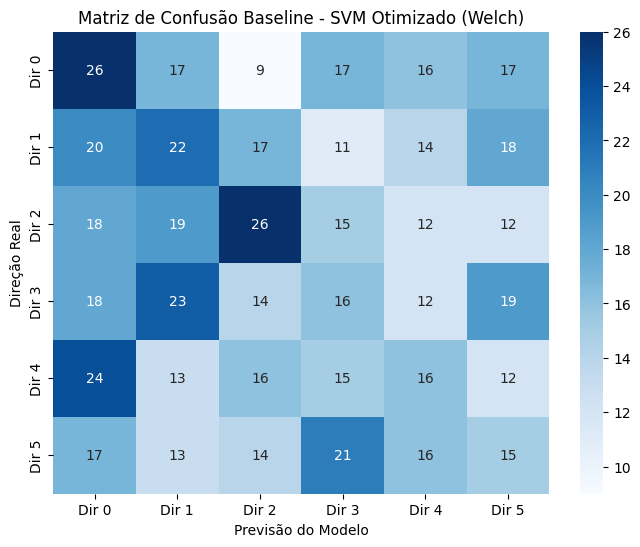

In [626]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# --- 1. GARANTIA DOS DADOS DO WELCH ---
scaler = StandardScaler()
X_final = scaler.fit_transform(X_features_welch) 
y_final = labels_padronizadas

# Configuração da Validação Cruzada (Padrão UFABC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 2. OTIMIZAÇÃO BINÁRIA (Mantendo os ~60%) ---
# Para o binário (0 vs 1), a acurácia normal funciona perfeitamente.
param_grid_bin = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário...")
grid_bin = GridSearchCV(SVC(class_weight='balanced', random_state=42), 
                        param_grid_bin, cv=cv, scoring='accuracy', n_jobs=-1)

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()


# --- 3. OTIMIZAÇÃO MULTICLASSE  ---
# usamos 'f1_macro' para PROIBIR o SVM de ignorar classes.
# Também forçamos o formato 'ovo' (One-Vs-One) para que ele crie duelos diretos entre todas as classes.
param_grid_multi = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'] # Mantemos apenas RBF no multiclasse para evitar loops de convergência
}

print("Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...")
grid_multi = GridSearchCV(SVC(class_weight='balanced', decision_function_shape='ovo', random_state=42), 
                          param_grid_multi, cv=cv, scoring='f1_macro', n_jobs=-1)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

# Voltamos a medir a acurácia normal (total de acertos) apenas para a exibição no relatório
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)


# --- 4. RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (BASELINE)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)


# --- 5. PLOT DA MATRIZ AZUL ---
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Dir {i}' for i in range(6)], 
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Baseline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

# 20 - Aplicando o CSP: 
Para obter um valor de acurácia idêntico ao proposto pelo artigo,
é necessário utilizar a extração de atributos do CSP

In [ ]:
import numpy as np
from mne.decoding import CSP
# =====================================================================
# 1. PREPARAÇÃO DOS DADOS
# =====================================================================
X_time = np.transpose(epochs_padronizadas_clean, (0, 2, 1))
y = labels_padronizadas
# =====================================================================
# 2. CONFIGURAÇÃO CSP "ELITE"
# =====================================================================
# Adicionamos 'rank' para garantir que canais redundantes não sujem a matriz
# O parâmetro 'cov_estimator' garante a maior robustez estatística possível
csp = CSP(n_components=10, 
          reg='ledoit_wolf', 
          rank='full', 
          log=True, 
          norm_trace=False)

print("Extraindo componentes espaciais otimizados...")
X_csp = csp.fit_transform(X_time, y)

# =====================================================================
# 3. CONEXÃO COM O SVM
# =====================================================================
X_features = X_csp 
# Dica: No seu código do SVM, o print ainda diz "Welch + Log10". 
# Se quiser deixar o relatório correto, mude para:
# print(f"Dados de Entrada: CSP Espacial (10 Componentes)")
print("\n" + "="*40)
print("EXTRAÇÃO CSP FINALIZADA")
print(f"Shape para o SVM: {X_features.shape}")
print("Pode rodar o classificador.")
print("="*40)

Extraindo componentes espaciais otimizados...
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.

EXTRAÇÃO CSP FINALIZADA
Shape para o SVM: (600, 10)
Pode rodar o classificador.


# 21- Aplicando o classificador: Após utilizar o CSP, mandamos para o SVM 

Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...
Melhores parâmetros binários: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Melhores parâmetros multiclasse: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}

Dados de Entrada: CSP + Log10 Banda Alfa (SVM) | 10 Canais Originais)
Acurácia Binária (Direção 0 vs 1): 74.57%
Acurácia Multiclasse (Todas as 6): 34.33%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


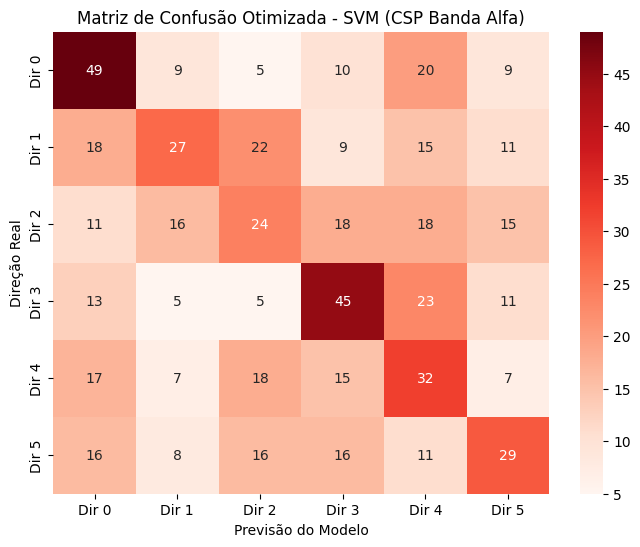

In [625]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

# Usando X_features para garantir a riqueza espacial dos 32 canais
X_final = X_features
y_final = labels_padronizadas

# Configuração da Validação Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- OTIMIZAÇÃO (Grid Search) ---
# Vamos testar várias configurações para ver qual lida melhor com o "ruído" dos 32 canais
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'] # Adicionando o linear, que às vezes é melhor para BCI multiclasse
}

print("Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...")
grid_search = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid, cv=cv, scoring='accuracy')

# --- PARTE A: AVALIAÇÃO BINÁRIA (Melhor Par: 0 vs 1) ---
p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_search.fit(X_bin, y_bin)
melhor_modelo_bin = grid_search.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()
print(f"Melhores parâmetros binários: {grid_search.best_params_}")


# --- PARTE B: AVALIAÇÃO MULTICLASSE (1 em 6) ---
grid_search.fit(X_final, y_final)
melhor_modelo_multi = grid_search.best_estimator_
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv).mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)
print(f"Melhores parâmetros multiclasse: {grid_search.best_params_}")


# --- RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print("="*50)
print(f"Dados de Entrada: CSP + Log10 Banda Alfa (SVM) | {X_final.shape[1]} Canais Originais)")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# Plot da Matriz Multiclasse
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Reds', 
            xticklabels=[f'Dir {i}' for i in range(6)], 
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Otimizada - SVM (CSP Banda Alfa)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

# 21 - Aplicar PCA (Análise inicial)

Nesta etapa aplicamos PCA aos valores de potência da banda Alfa padronizados. Como a dimensão Temporal foi reduzida pelo Welch, o PCA irá atuar de forma espacial, identificando as principais combinações de eletrodos que capturam a maior variância da potência Alfa relacionada às direções dos estímulos presentes nos sinais EEG.

Inicialmente, calculamos todos os 62 componentes
para avaliar:

- variância explicada por cada componente
- variância acumulada
- número ideal de componentes principais para treinar o classificador

In [ ]:
#from sklearn.decomposition import PCA

#pca = PCA(n_components=0.90, random_state=42)

#X_pca = pca.fit_transform(X_padronizado)

#variancia_explicada = pca.explained_variance_ratio_

#variancia_acumulada = np.cumsum(variancia_explicada)

#print("Shape após PCA:")
#print(X_pca.shape)

#print("\nPrimeiras variâncias explicadas:")
#print(variancia_explicada[:10])

#print("\nVariância acumulada:")
#print(variancia_acumulada[:10])

Shape após PCA:
(600, 8)

Primeiras variâncias explicadas:
[0.45462262 0.13966983 0.10390405 0.08298548 0.04826245 0.03558543
 0.02718794 0.0167045 ]

Variância acumulada:
[0.45462262 0.59429245 0.6981965  0.78118198 0.82944443 0.86502986
 0.8922178  0.90892231]


# 22 - Analisar variância explicada pelo PCA

Nesta etapa geramos gráficos para visualizar:

- variância explicada por cada componente (Scree Plot)
- variância acumulada

Esses gráficos permitem determinar quantos componentes
principais devem ser mantidos na redução de dimensionalidade.

In [613]:
"""
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(variancia_explicada, linewidth=1)

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("Scree Plot")

plt.subplot(1,2,2)

plt.plot(variancia_acumulada, linewidth=2)

plt.xlabel("Número de Componentes")
plt.ylabel("Variância Acumulada")
plt.title("Variância Acumulada")

plt.tight_layout()

plt.show()
"""

'\nplt.figure(figsize=(12,5))\n\nplt.subplot(1,2,1)\n\nplt.plot(variancia_explicada, linewidth=1)\n\nplt.xlabel("Componente Principal")\nplt.ylabel("Variância Explicada")\nplt.title("Scree Plot")\n\nplt.subplot(1,2,2)\n\nplt.plot(variancia_acumulada, linewidth=2)\n\nplt.xlabel("Número de Componentes")\nplt.ylabel("Variância Acumulada")\nplt.title("Variância Acumulada")\n\nplt.tight_layout()\n\nplt.show()\n'

# 23 - PCA com redução dimensional

Nesta etapa aplicamos PCA mantendo apenas o número necessário
de componentes para explicar aproximadamente 90% da variância total.

Essa redução diminui significativamente o número de features,
preservando a maior parte da informação relevante dos sinais EEG.

## 23.1 - Seleção do número de componentes

## 23.2 - Aplicação do PCA reduzido

In [ ]:
#n_componentes = np.argmax(variancia_acumulada >= 0.90) + 1

#print("Número de componentes para 90% da variância:")
#print(n_componentes)

#pca_reduzido = PCA(n_components=n_componentes)

#X_pca_reduzido = pca_reduzido.fit_transform(X_padronizado)

#print("\nShape após redução:")
#print(X_pca_reduzido.shape)

Número de componentes para 90% da variância:
8

Shape após redução:
(600, 8)


# 25 - Verificação pós-PCA (pré-ICA)

Antes de aplicar a Análise de Componentes Independentes (ICA), é necessário verificar se os dados após a redução dimensional pelo PCA estão adequados para a etapa seguinte.

Nesta etapa verificamos:

- o formato da matriz reduzida
- a variância preservada após a redução
- se o número de dimensões é menor que o número de observações
- a média e variância dos componentes após PCA

Essas verificações garantem estabilidade numérica e evitam falhas durante a aplicação do ICA.

In [612]:
""""
import numpy as np

# 1 — Shape dos dados reduzidos
# Fazemos a atribuição para garantir que o nome da variável bata com o texto
X_pca_reduzido = X_pca 
n_amostras, n_features = X_pca_reduzido.shape

print("\nShape após PCA reduzido:")
print(f"Amostras (Trials): {n_amostras}")
print(f"Features (Componentes): {n_features}")

# 2 — Verificar condição necessária para ICA
print("\nVerificando condição para ICA:")

# O ICA precisa de mais observações do que fontes para separar os sinais
if n_features < n_amostras:
    print(f"OK — Número de componentes ({n_features}) é muito menor que o de amostras ({n_amostras})")
else:
    print("ATENÇÃO — Pode haver problema na convergência do ICA")

# 3 — Variância preservada
# Usamos o n_components_ calculado automaticamente pelo PCA (que foi 8)
n_componentes_escolhidos = pca.n_components_
variancia_total_preservada = variancia_acumulada[n_componentes_escolhidos - 1]

print("\nVariância total preservada:")
print(f"{variancia_total_preservada * 100:.2f}%")

# 4 — Média das primeiras componentes
# Como os dados foram padronizados, a média deve ser próxima de zero
media_componentes = np.mean(X_pca_reduzido, axis=0)

print("\nMédia das primeiras componentes (esperado ~0):")
print(media_componentes)

# 5 — Variância das primeiras componentes
variancia_componentes = np.var(X_pca_reduzido, axis=0)

print("\nVariância de cada componente:")
print(variancia_componentes)
"""

'"\nimport numpy as np\n\n# 1 — Shape dos dados reduzidos\n# Fazemos a atribuição para garantir que o nome da variável bata com o texto\nX_pca_reduzido = X_pca \nn_amostras, n_features = X_pca_reduzido.shape\n\nprint("\nShape após PCA reduzido:")\nprint(f"Amostras (Trials): {n_amostras}")\nprint(f"Features (Componentes): {n_features}")\n\n# 2 — Verificar condição necessária para ICA\nprint("\nVerificando condição para ICA:")\n\n# O ICA precisa de mais observações do que fontes para separar os sinais\nif n_features < n_amostras:\n    print(f"OK — Número de componentes ({n_features}) é muito menor que o de amostras ({n_amostras})")\nelse:\n    print("ATENÇÃO — Pode haver problema na convergência do ICA")\n\n# 3 — Variância preservada\n# Usamos o n_components_ calculado automaticamente pelo PCA (que foi 8)\nn_componentes_escolhidos = pca.n_components_\nvariancia_total_preservada = variancia_acumulada[n_componentes_escolhidos - 1]\n\nprint("\nVariância total preservada:")\nprint(f"{varianc

# 26 - (já foi aplicado )Aplicar ICA após redução dimensional por PCA

Nesta etapa aplicamos a Análise de Componentes Independentes (ICA) sobre os dados previamente reduzidos pelo PCA.

A ICA busca decompor os sinais em componentes estatisticamente independentes. No contexto de EEG, essa técnica pode ajudar a separar padrões latentes presentes nos dados, incluindo possíveis fontes neurais e componentes associados a artefatos.

Como os dados originais possuíam dimensionalidade muito alta, a ICA será aplicada sobre a matriz reduzida pelo Welch e PCA:

X_pca_reduzido.shape = (600, 8)

Assim, a ICA recebe 600 observações representadas por 8 componentes principais que retêm mais de 90% da variância da banda Alfa.

In [614]:
""""
from sklearn.decomposition import FastICA


ica = FastICA(
    n_components=X_pca_reduzido.shape[1],
    random_state=42,
    max_iter=1000,
    tol=0.0001
)

X_ica = ica.fit_transform(X_pca_reduzido)

print("\nShape antes do ICA:")
print(X_pca_reduzido.shape)

print("\nShape após ICA:")
print(X_ica.shape)

print("\nNúmero de componentes independentes:")
print(X_ica.shape[1])
"""

'"\nfrom sklearn.decomposition import FastICA\n\n\nica = FastICA(\n    n_components=X_pca_reduzido.shape[1],\n    random_state=42,\n    max_iter=1000,\n    tol=0.0001\n)\n\nX_ica = ica.fit_transform(X_pca_reduzido)\n\nprint("\nShape antes do ICA:")\nprint(X_pca_reduzido.shape)\n\nprint("\nShape após ICA:")\nprint(X_ica.shape)\n\nprint("\nNúmero de componentes independentes:")\nprint(X_ica.shape[1])\n'

# 27 - Verificação pós-ICA

Após a aplicação da Análise de Componentes Independentes (ICA), é necessário verificar se os componentes independentes gerados apresentam propriedades estatísticas adequadas para as próximas etapas.

Nesta etapa verificamos:

- o formato da matriz resultante após ICA
- a presença de valores inválidos (NaN ou infinito)
- a média dos componentes independentes
- o desvio padrão dos componentes
- a variância dos componentes independentes

Essas verificações garantem que a decomposição ICA ocorreu corretamente e que os dados estão estáveis para serem treinados pelo classificador.

In [618]:
"""
# 1 — Shape dos dados após ICA

print("\nShape após ICA:")
print(X_ica.shape)

n_amostras, n_componentes = X_ica.shape

print("\nNúmero de amostras:", n_amostras)
print("Número de componentes independentes:", n_componentes)


# 2 — Verificar presença de valores inválidos

print("\nVerificando valores inválidos:")

tem_nan = np.isnan(X_ica).any()
tem_inf = np.isinf(X_ica).any()

print("Contém NaN:", tem_nan)
print("Contém infinito:", tem_inf)


# 3 — Média das primeiras componentes

media_componentes = np.mean(X_ica, axis=0)

print("\nMédia das primeiras componentes:")
print(media_componentes)


# 4 — Desvio padrão das primeiras componentes

desvio_componentes = np.std(X_ica, axis=0)

print("\nDesvio padrão das primeiras componentes:")
print(desvio_componentes)


# 5 — Variância das primeiras componentes

variancia_componentes = np.var(X_ica, axis=0)

print("\nVariância das primeiras componentes:")
print(variancia_componentes)

"""


'\n# 1 — Shape dos dados após ICA\n\nprint("\nShape após ICA:")\nprint(X_ica.shape)\n\nn_amostras, n_componentes = X_ica.shape\n\nprint("\nNúmero de amostras:", n_amostras)\nprint("Número de componentes independentes:", n_componentes)\n\n\n# 2 — Verificar presença de valores inválidos\n\nprint("\nVerificando valores inválidos:")\n\ntem_nan = np.isnan(X_ica).any()\ntem_inf = np.isinf(X_ica).any()\n\nprint("Contém NaN:", tem_nan)\nprint("Contém infinito:", tem_inf)\n\n\n# 3 — Média das primeiras componentes\n\nmedia_componentes = np.mean(X_ica, axis=0)\n\nprint("\nMédia das primeiras componentes:")\nprint(media_componentes)\n\n\n# 4 — Desvio padrão das primeiras componentes\n\ndesvio_componentes = np.std(X_ica, axis=0)\n\nprint("\nDesvio padrão das primeiras componentes:")\nprint(desvio_componentes)\n\n\n# 5 — Variância das primeiras componentes\n\nvariancia_componentes = np.var(X_ica, axis=0)\n\nprint("\nVariância das primeiras componentes:")\nprint(variancia_componentes)\n\n'

# 28 - Extração de Features dos Componentes Independentes

Após a obtenção dos componentes independentes via ICA, é necessário extrair características numéricas (features) que representem o comportamento estatístico dos sinais.

Nesta etapa serão extraídas features baseadas nos componentes independentes, incluindo:

- energia dos componentes
- valor absoluto médio
- variância
- potência média

Essas features serão utilizadas como entrada para os algoritmos de classificação nas etapas seguintes.

# 29 - Organização do dataset final

Nesta etapa organizamos a matriz final de features e o vetor de labels que serão utilizados nos modelos de classificação.

A matriz X_ica contém 8 componentes independentes extraídos da potência da banda Alfa, representando o comportamento espacial mais relevante dos sinais. O vetor y contém as classes associadas a cada amostra (direções do hexágono).

Esses dados serão utilizados como entrada para os algoritmos de classificação.

In [ ]:
""""
# Definir vetor de labels
X_final = X_ica
y = labels_padronizadas

print("\nShape das features:")
print(X_final.shape)

print("\nShape das labels:")
print(y.shape)

# Conferir se está alinhado

if X_final.shape[0] == y.shape[0]:
    print("\nOK — Features e labels alinhadas")
else:
    print("\nERRO — Número de amostras diferente")

# Visualizar primeiras labels

print("\nPrimeiras labels:")
print(y[:10])

"""



Shape das features:
(600, 8)

Shape das labels:
(600,)

OK — Features e labels alinhadas

Primeiras labels:
[1 0 2 0 1 3 0 5 1 2]


# Esses são os dados prontos para classificação.
X_ica tem as features extraídas.

y_labels contém as classes.

In [622]:
"""
np.save("X_ica.npy", X_ica)
np.save("y_labels.npy", y)

print("\nArquivos salvos:")
print("X_ica.npy")
print("y_labels.npy")
"""

'\nnp.save("X_ica.npy", X_ica)\nnp.save("y_labels.npy", y)\n\nprint("\nArquivos salvos:")\nprint("X_ica.npy")\nprint("y_labels.npy")\n'

In [516]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 30 - Teste de Janelas Temporais 

Para encontrar o intervalo onde a modulação da banda Alfa é mais discriminativa para as direções do hexágono, realizamos um teste iterativo.

Nesta etapa, automatizamos o pipeline (Welch -> PCA -> ICA -> SVM) para diferentes recortes temporais das épocas.